## 0. Environment Setup

In [1]:
import warnings
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "accent": "#AB47BC",
    "neutral": "#B0BEC5",
}

# ── V3 Architecture Constants ────────────────────────────────────────────────
EMBEDDING_DIM_STRUCTURAL = 32  # GNN output dimension per node
ROLLING_CORR_WINDOW = 30  # days for dynamic edge weights (§3-C)
CORR_EDGE_THRESHOLD = 0.40  # Minimum |correlation| to include edge
GNN_HIDDEN_DIM = 64  # GATv2 hidden dimension
GNN_N_HEADS = 4  # Attention heads per GATv2 layer
REDIS_TTL_GRAPH = 7200  # Graph embedding cache TTL (2h, from constants.py)

# ── Asset universe — GNN nodes (§3-C: "Nodes: Assets (SPY, AAPL, MSFT, VIX, Oil, Gold)") ─
UNIVERSE = {
    "SPY": {"sector": "ETF", "asset_class": "equity"},
    "AAPL": {"sector": "Tech", "asset_class": "equity"},
    "MSFT": {"sector": "Tech", "asset_class": "equity"},
    "NVDA": {"sector": "Semiconductor", "asset_class": "equity"},
    "AMD": {"sector": "Semiconductor", "asset_class": "equity"},
    "SMCI": {"sector": "Tech Hardware", "asset_class": "equity"},
    "GLD": {"sector": "Commodity", "asset_class": "commodity"},
    "USO": {"sector": "Energy", "asset_class": "commodity"},
    "^VIX": {"sector": "Volatility", "asset_class": "derivative"},
    "TLT": {"sector": "Bond", "asset_class": "fixed_income"},
    "QQQ": {"sector": "ETF", "asset_class": "equity"},
    "GOOGL": {"sector": "Tech", "asset_class": "equity"},
}

# ── Static supply-chain edges (§3-C: "Static Edges: Supply chain relationships") ──
STATIC_EDGES = [
    ("NVDA", "SMCI", 0.80),  # SMCI is major NVDA customer
    ("NVDA", "AMD", 0.70),  # Competitors — high structural correlation
    ("AAPL", "MSFT", 0.65),  # Sector peers
    ("AAPL", "GOOGL", 0.60),  # Sector peers
    ("SPY", "QQQ", 0.90),  # ETF overlap (QQQ is in SPY)
]

END = datetime.today()
START = END - timedelta(days=365 * 3)

print(f"GNN Universe: {len(UNIVERSE)} nodes")
print(f"Static supply-chain edges: {len(STATIC_EDGES)}")
print(f"Dynamic edge threshold: |corr| > {CORR_EDGE_THRESHOLD}")

GNN Universe: 12 nodes
Static supply-chain edges: 5
Dynamic edge threshold: |corr| > 0.4


## 1. Price Data Download

In [2]:
prices: dict[str, pd.Series] = {}
tickers_clean = UNIVERSE.keys()

for t in tickers_clean:
    try:
        df = yf.download(
            t, start=START, end=END, progress=False, auto_adjust=True
        )
        prices[t] = df["Close"].squeeze()
    except Exception as e:
        print(f"  {t} → ERROR: {e}")

close_df = pd.DataFrame(prices).dropna()
returns = close_df.pct_change().dropna()
print(f"\nClose matrix: {close_df.shape}  |  Return matrix: {returns.shape}")


Close matrix: (752, 12)  |  Return matrix: (751, 12)


## 2. Dynamic Edge Construction — Rolling 30-Day Correlation

In [3]:
# "Dynamic Edges: Rolling 30-day price correlation (updated daily).
#  High correlation → Strong edge weight." (§3-C)


def build_dynamic_adjacency(
    returns: pd.DataFrame,
    window: int = ROLLING_CORR_WINDOW,
    threshold: float = CORR_EDGE_THRESHOLD,
) -> dict:
    """
    Compute rolling correlation matrices.
    Returns dict of {date: adjacency_matrix (n_nodes × n_nodes)}.
    Implements backend/perception/structural/dynamic_edges.py logic.
    """
    nodes = list(returns.columns)
    n = len(nodes)
    adj_by_date = {}

    for i in range(window, len(returns)):
        window_ret = returns.iloc[i - window : i]
        corr = window_ret.corr().values
        # Zero out self-loops and sub-threshold edges
        np.fill_diagonal(corr, 0)
        corr[np.abs(corr) < threshold] = 0
        adj_by_date[returns.index[i]] = corr

    return adj_by_date, nodes


adj_history, node_list = build_dynamic_adjacency(returns)
print(f"Adjacency matrices computed: {len(adj_history)}")

# Get the most recent adjacency matrix
latest_date = max(adj_history.keys())
latest_adj = adj_history[latest_date]
print(f"Latest adjacency matrix ({latest_date.date()}):")
print(f"  Non-zero edges: {(np.abs(latest_adj) > 0).sum() // 2}")

Adjacency matrices computed: 721
Latest adjacency matrix (2026-03-11):
  Non-zero edges: 20


## 3. Graph Visualisation — Dynamic Market Network

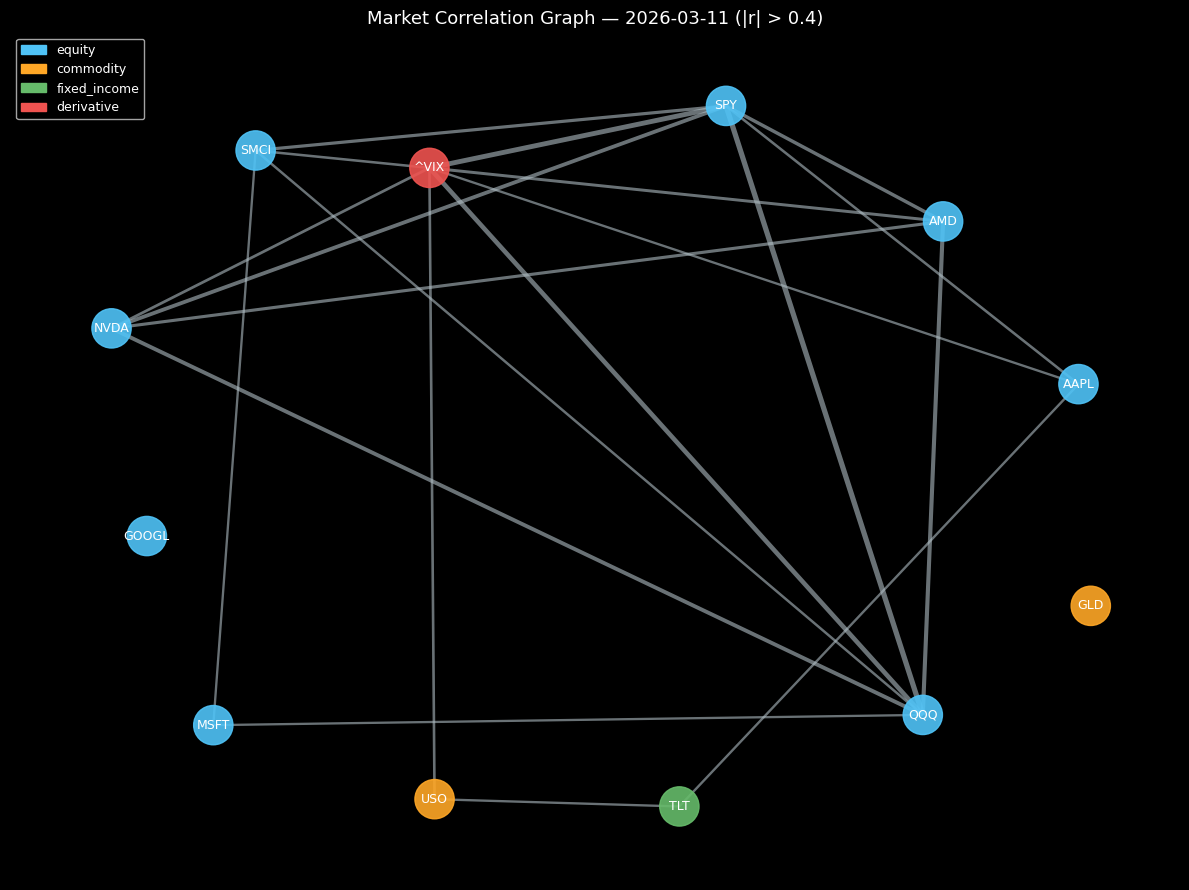

In [4]:
def plot_market_graph(adj: np.ndarray, nodes: list, title: str) -> None:
    """
    Visualise the market correlation graph as a NetworkX plot.
    Node colour = asset class, edge thickness = correlation strength.
    """
    G = nx.Graph()
    G.add_nodes_from(nodes)

    asset_colors = {
        "equity": COLORS["primary"],
        "commodity": COLORS["warning"],
        "fixed_income": COLORS["success"],
        "derivative": COLORS["danger"],
    }

    for i, ni in enumerate(nodes):
        for j, nj in enumerate(nodes):
            if i < j and abs(adj[i, j]) > 0:
                G.add_edge(ni, nj, weight=adj[i, j])

    node_colors = [
        asset_colors.get(
            UNIVERSE.get(n, {}).get("asset_class", "equity"), COLORS["neutral"]
        )
        for n in nodes
    ]

    pos = nx.spring_layout(G, seed=42, k=2.5)
    weights = [G[u][v]["weight"] for u, v in G.edges()]

    fig, ax = plt.subplots(figsize=(12, 9))
    nx.draw_networkx_nodes(
        G, pos, node_color=node_colors, node_size=800, alpha=0.9, ax=ax
    )
    nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", ax=ax)
    nx.draw_networkx_edges(
        G,
        pos,
        width=[w * 4 for w in weights],
        alpha=0.6,
        edge_color=COLORS["neutral"],
        ax=ax,
    )

    # Legend
    legend_patches = [
        mpatches.Patch(color=c, label=cls) for cls, c in asset_colors.items()
    ]
    ax.legend(handles=legend_patches, loc="upper left", fontsize=9)
    ax.set_title(title, fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("07/07_market_graph.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_market_graph(
    latest_adj,
    node_list,
    f"Market Correlation Graph — {latest_date.date()} "
    f"(|r| > {CORR_EDGE_THRESHOLD})",
)

## 4. Edge Weight Evolution Over Time

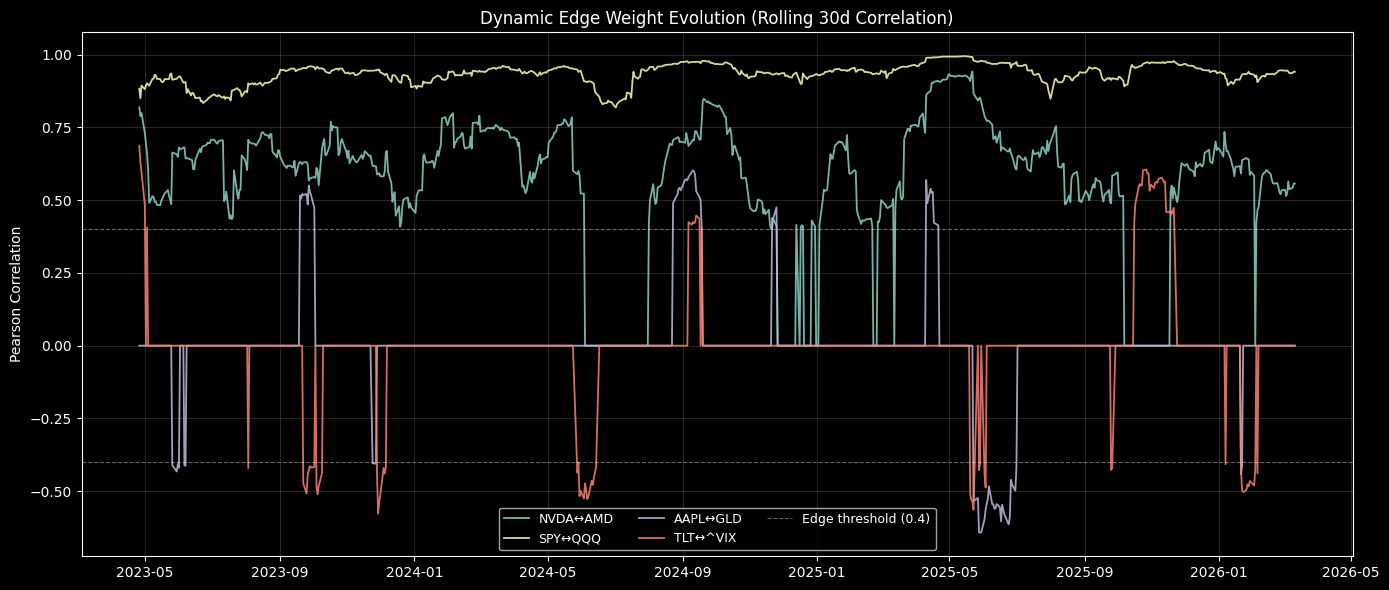

In [5]:
# Track how key edges (NVDA→AMD, SPY→QQQ) evolve during market stress.
dates = sorted(adj_history.keys())
n_dates = len(dates)
node_idx = {n: i for i, n in enumerate(node_list)}

TRACKED_PAIRS = [
    ("NVDA", "AMD"),
    ("SPY", "QQQ"),
    ("AAPL", "GLD"),
    ("TLT", "^VIX"),
]
edge_series: dict[str, list] = {f"{a}↔{b}": [] for a, b in TRACKED_PAIRS}

for date in dates:
    adj = adj_history[date]
    for a, b in TRACKED_PAIRS:
        if a in node_idx and b in node_idx:
            corr = adj[node_idx[a], node_idx[b]]
            edge_series[f"{a}↔{b}"].append(corr)
        else:
            edge_series[f"{a}↔{b}"].append(np.nan)

date_index = pd.DatetimeIndex(dates)

fig, ax = plt.subplots(figsize=(14, 6))
for label, series in edge_series.items():
    ax.plot(date_index, series, linewidth=1.3, label=label, alpha=0.85)

ax.axhline(
    CORR_EDGE_THRESHOLD,
    color="white",
    linestyle="--",
    alpha=0.4,
    linewidth=0.8,
    label=f"Edge threshold ({CORR_EDGE_THRESHOLD})",
)
ax.axhline(
    -CORR_EDGE_THRESHOLD,
    color="white",
    linestyle="--",
    alpha=0.4,
    linewidth=0.8,
)
ax.set_title(
    f"Dynamic Edge Weight Evolution (Rolling {ROLLING_CORR_WINDOW}d Correlation)"
)
ax.set_ylabel("Pearson Correlation")
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("07/07_edge_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Hierarchical Clustering — Static Graph Structure

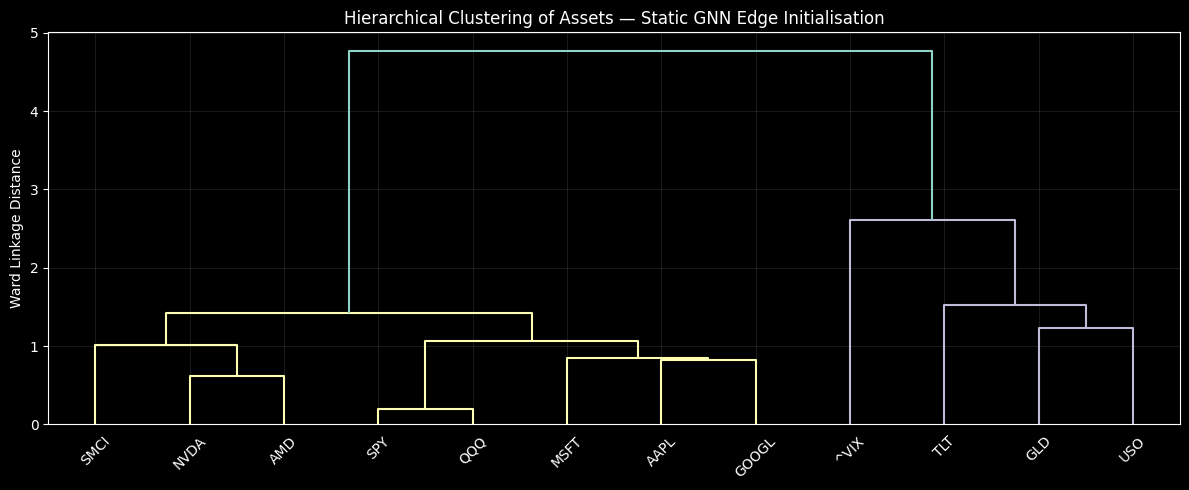

In [6]:
# Identify natural asset clusters for static edge initialisation.
full_corr = returns.corr()
linkage_matrix = linkage(full_corr.values, method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=full_corr.columns.tolist(),
    ax=ax,
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=0.8 * max(linkage_matrix[:, 2]),
)
ax.set_title(
    "Hierarchical Clustering of Assets — Static GNN Edge Initialisation"
)
ax.set_ylabel("Ward Linkage Distance")
ax.grid(alpha=0.10)
plt.tight_layout()
plt.savefig("07/07_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. GATv2 Graph Neural Network Architecture

In [7]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class GATv2Layer(nn.Module):
        """
        Graph Attention Network v2 (GATv2) layer.
        GATv2 fixes the expressiveness limitation of GATv1 by computing
        attention as: e_ij = a^T · LeakyReLU(W_l · h_i + W_r · h_j)
        where W_l ≠ W_r (asymmetric attention).

        Reference: Brody et al. 2021, "How Attentive are Graph Attention Networks?"
        Implements: backend/perception/structural/gnn_model.py
        """

        def __init__(
            self,
            in_dim: int,
            out_dim: int,
            n_heads: int = GNN_N_HEADS,
            dropout: float = 0.1,
            concat_heads: bool = True,
        ):
            super().__init__()
            self.n_heads = n_heads
            self.out_dim = out_dim
            self.concat_heads = concat_heads
            head_dim = out_dim // n_heads if concat_heads else out_dim

            # GATv2 asymmetric linear projections
            self.W_l = nn.Linear(in_dim, head_dim * n_heads, bias=False)
            self.W_r = nn.Linear(in_dim, head_dim * n_heads, bias=False)
            self.attn_vec = nn.Parameter(torch.randn(1, n_heads, head_dim))

            self.leaky_relu = nn.LeakyReLU(0.2)
            self.dropout = nn.Dropout(dropout)
            self.ln = nn.LayerNorm(out_dim)

        def forward(self, h: torch.Tensor, adj: torch.Tensor) -> tuple:
            """
            Args:
                h   : (n_nodes, in_dim)   node feature matrix
                adj : (n_nodes, n_nodes)  weighted adjacency matrix
            Returns:
                out : (n_nodes, out_dim)  updated node embeddings
                attn_weights: (n_heads, n_nodes, n_nodes)
            """
            n = h.shape[0]
            head_dim = self.out_dim // self.n_heads

            h_l = self.W_l(h).view(n, self.n_heads, head_dim)  # (n, H, d)
            h_r = self.W_r(h).view(n, self.n_heads, head_dim)

            # Pairwise attention scores (broadcast)
            # e_ij = a^T · LeakyReLU(h_l_i + h_r_j)
            h_l_exp = h_l.unsqueeze(1).expand(-1, n, -1, -1)  # (n, n, H, d)
            h_r_exp = h_r.unsqueeze(0).expand(n, -1, -1, -1)

            e = self.leaky_relu(h_l_exp + h_r_exp)  # (n, n, H, d)
            e = (e * self.attn_vec).sum(dim=-1)  # (n, n, H)
            e = e.permute(2, 0, 1)  # (H, n, n)

            # Mask padded edges (adj == 0 → -inf before softmax)
            mask = (adj == 0).unsqueeze(0).expand(self.n_heads, -1, -1)
            e = e.masked_fill(mask, float("-inf"))

            # Normalised attention weights
            attn = F.softmax(e, dim=-1)
            attn = self.dropout(attn)

            # Weighted message aggregation
            h_r_heads = h_r.permute(1, 0, 2)  # (H, n, d)
            out = torch.bmm(attn, h_r_heads)  # (H, n, d)
            out = out.permute(1, 0, 2)  # (n, H, d)
            out = out.reshape(n, -1)  # (n, H*d = out_dim)

            return self.ln(F.elu(out)), attn

    class GNNStructuralEncoder(nn.Module):
        """
        Multi-layer GATv2 encoder that produces a 32-dimensional structural
        embedding for each node (asset) in the market graph.

        "If the Semiconductor neighbours are crashing, the GNN embedding for
         AAPL will reflect 'neighbourhood stress' even if AAPL hasn't dropped
         yet." (§3-C)

        Maps to: backend/perception/structural/gnn_model.py → class GNNEncoder
        """

        def __init__(
            self,
            in_dim: int,
            hidden_dim: int = GNN_HIDDEN_DIM,
            output_dim: int = EMBEDDING_DIM_STRUCTURAL,
            n_heads: int = GNN_N_HEADS,
            n_layers: int = 2,
            dropout: float = 0.1,
        ):
            super().__init__()
            self.layers = nn.ModuleList()

            # Layer 1: in → hidden
            self.layers.append(
                GATv2Layer(in_dim, hidden_dim, n_heads, dropout)
            )
            # Hidden layers
            for _ in range(n_layers - 2):
                self.layers.append(
                    GATv2Layer(hidden_dim, hidden_dim, n_heads, dropout)
                )
            # Last layer: hidden → 32d output
            self.layers.append(
                GATv2Layer(hidden_dim, output_dim, n_heads=1, dropout=0.0)
            )

            self.drop = nn.Dropout(dropout)

        def forward(self, x: torch.Tensor, adj: torch.Tensor) -> tuple:
            """
            Args:
                x   : (n_nodes, in_dim)   node features
                adj : (n_nodes, n_nodes)  adjacency (weighted + symmetric)
            Returns:
                embeddings : (n_nodes, 32) — structural embeddings per asset
                attn_maps  : list of (H, n, n) attention maps per layer
            """
            h = x
            attn_maps = []
            for layer in self.layers:
                h, attn = layer(h, adj)
                h = self.drop(h)
                attn_maps.append(attn)
            return h, attn_maps

    # Test forward pass
    n_nodes = len(node_list)
    node_feat_dim = 16  # node features: return, volatility, beta, RSI, etc.

    gnn = GNNStructuralEncoder(in_dim=node_feat_dim).to(DEVICE)
    n_params = sum(p.numel() for p in gnn.parameters() if p.requires_grad)

    # Dummy forward pass
    x_dummy = torch.randn(n_nodes, node_feat_dim).to(DEVICE)
    adj_dummy = torch.tensor(latest_adj, dtype=torch.float32).to(DEVICE)

    gnn.eval()
    with torch.no_grad():
        emb, attn_maps = gnn(x_dummy, adj_dummy)

    print("GNNStructuralEncoder ✅")
    print(f"  Nodes           : {n_nodes}")
    print(f"  Node feat. dim  : {node_feat_dim}")
    print(
        f"  Output dim      : {EMBEDDING_DIM_STRUCTURAL} (EMBEDDING_DIM_STRUCTURAL)"
    )
    print(f"  Trainable params: {n_params:,}")
    print(f"  Embedding shape : {emb.shape}")

except ImportError:
    print("PyTorch not installed — skipping GNN model definition.")
    print("Run: pip install torch")

GNNStructuralEncoder ✅
  Nodes           : 12
  Node feat. dim  : 16
  Output dim      : 32 (EMBEDDING_DIM_STRUCTURAL)
  Trainable params: 6,432
  Embedding shape : torch.Size([12, 32])


## 7. Node Feature Construction

In [8]:
# Build the node feature matrix that feeds into the GNN.
# Each node (asset) gets a feature vector: rolling statistics on its return series.
def build_node_features(
    returns: pd.DataFrame, window: int = 30
) -> pd.DataFrame:
    """
    Compute per-node feature vector for GNN input.
    Features capture the recent market state of each asset.
    """
    latest = returns.iloc[-window:]
    features = pd.DataFrame(index=returns.columns)

    features["mean_return"] = latest.mean()
    features["volatility"] = latest.std()
    features["skewness"] = latest.skew()
    features["kurtosis"] = latest.kurtosis()
    features["max_drawdown"] = (latest.cummax() - latest).max()
    features["positive_days"] = (latest > 0).mean()
    features["trend_30d"] = latest.mean() / (
        latest.std() + 1e-10
    )  # Sharpe proxy
    features["beta_vs_spy"] = latest.corrwith(
        latest.get("SPY", latest.iloc[:, 0])
    )

    # RSI at node level
    delta = latest.diff()
    gain = delta.clip(lower=0).mean()
    loss = (-delta.clip(upper=0)).mean()
    rsi = 100 - 100 / (1 + gain / (loss + 1e-10))
    features["rsi"] = rsi

    # Normalise
    from sklearn.preprocessing import StandardScaler

    scaled = StandardScaler().fit_transform(features.fillna(0))
    return pd.DataFrame(scaled, index=features.index, columns=features.columns)


node_features_df = build_node_features(returns)
print(f"Node feature matrix: {node_features_df.shape}")
print(node_features_df.to_string())

Node feature matrix: (12, 9)
       mean_return  volatility  skewness  kurtosis  max_drawdown  positive_days  trend_30d  beta_vs_spy       rsi
SPY      -0.359027   -0.973191  0.282821 -0.783268     -1.020626      -1.048265  -0.728222     1.325804  0.025408
AAPL     -0.144262   -0.536390 -0.439319 -0.073781     -0.447060       0.431638   0.247303     0.284164  1.240010
MSFT     -1.013148   -0.226474 -2.127012  2.055449     -0.328579      -0.678289  -1.337560     0.145452 -0.157805
NVDA     -0.243647   -0.177928  0.426556 -0.106691     -0.009001       0.801614   0.017355     0.713528 -0.370422
AMD      -1.050434    0.752053 -1.068476  1.243738      0.813101      -1.048265  -0.710314     0.588403  0.704160
SMCI      0.052545    0.847386  1.170565 -0.330306      0.921833      -0.678289   0.293908     0.503843  0.506169
GLD      -0.162121    0.034319 -1.268263  0.576403      0.075469       0.801614   0.138059    -0.258453 -2.045092
USO       1.545849    0.147009  1.325555  1.090279      0.3

## 8. Structural Embedding Forward Pass with Real Node Features

Structural embeddings shape: (12, 32)

Embedding norms per asset (higher = richer structural context):
  SPY      : nan
  AAPL     : nan
  MSFT     : nan
  NVDA     : nan
  AMD      : nan
  SMCI     : nan
  GLD      : nan
  USO      : nan
  ^VIX     : nan
  TLT      : nan
  QQQ      : nan
  GOOGL    : nan


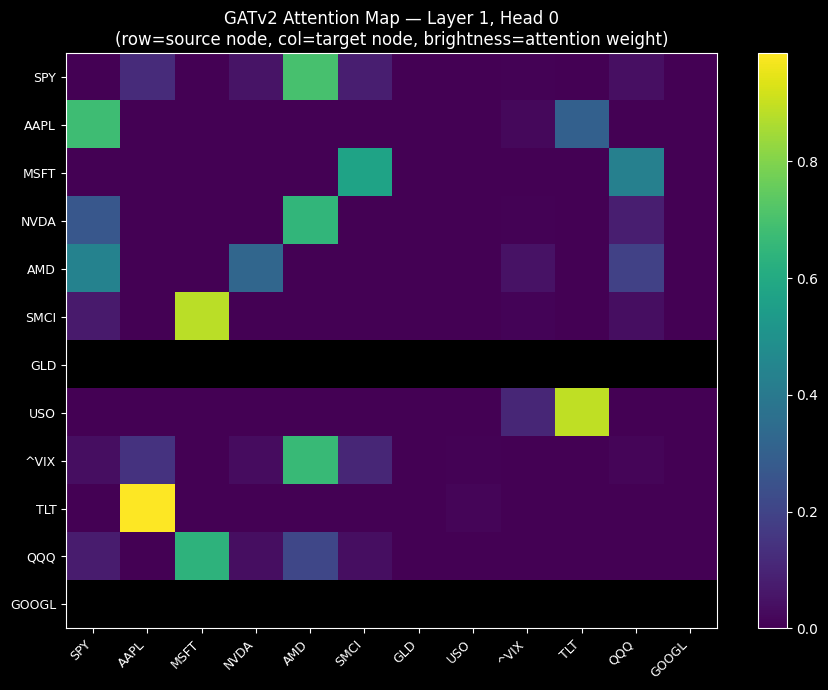


Saved structural embeddings → 07_structural_embeddings.npy
Shape: (12, 32)  (n_nodes, EMBEDDING_DIM_STRUCTURAL=32)


In [9]:
try:
    node_feat_real = torch.tensor(
        node_features_df.values, dtype=torch.float32
    ).to(DEVICE)
    adj_real = torch.tensor(latest_adj, dtype=torch.float32).to(DEVICE)

    # Rebuild GNN with correct input dimension
    gnn_real = GNNStructuralEncoder(in_dim=node_features_df.shape[1]).to(
        DEVICE
    )

    gnn_real.eval()
    with torch.no_grad():
        structural_embeddings, attn_maps = gnn_real(node_feat_real, adj_real)

    emb_np = structural_embeddings.cpu().numpy()  # (n_nodes, 32)
    print(f"Structural embeddings shape: {emb_np.shape}")

    # Per-node embedding norms — higher norm = richer structural signal
    norms = np.linalg.norm(emb_np, axis=1)
    print("\nEmbedding norms per asset (higher = richer structural context):")
    for ticker, norm in sorted(
        zip(node_list, norms, strict=False), key=lambda x: -x[1]
    ):
        print(f"  {ticker:<8} : {norm:.4f}")

    # Attention map visualisation (Layer 1, Head 0)
    if attn_maps:
        attn_l1 = attn_maps[0][0].cpu().numpy()  # (n_nodes, n_nodes)
        fig, ax = plt.subplots(figsize=(9, 7))
        im = ax.imshow(attn_l1, cmap="viridis", aspect="auto")
        ax.set_xticks(range(n_nodes))
        ax.set_yticks(range(n_nodes))
        ax.set_xticklabels(node_list, rotation=45, ha="right", fontsize=9)
        ax.set_yticklabels(node_list, fontsize=9)
        ax.set_title(
            "GATv2 Attention Map — Layer 1, Head 0\n"
            "(row=source node, col=target node, brightness=attention weight)"
        )
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.savefig("07/07_gnn_attention.png", dpi=150, bbox_inches="tight")
        plt.show()

    # Save embeddings for notebook 08 (Fusion Layer)
    np.save("07/07_structural_embeddings.npy", emb_np)
    np.save("07/07_node_list.npy", np.array(node_list))
    print("\nSaved structural embeddings → 07_structural_embeddings.npy")
    print(f"Shape: {emb_np.shape}  (n_nodes, EMBEDDING_DIM_STRUCTURAL=32)")

except Exception as e:
    print(f"Skipping real forward pass: {e}")

## 9. Redis Payload Format — Graph Embeddings

In [10]:
# Defines the Redis key-value structure for structural embeddings.
# TTL = 7200s (2h) because graph structure is updated hourly.
# Implements backend/perception/structural/gnn_model.py → export_to_redis()


def build_graph_redis_payloads(
    emb_matrix: np.ndarray, nodes: list
) -> list[dict]:
    """
    Create per-asset Redis payloads for structural embeddings.
    Key pattern: embeddings:graph:{ticker}
    TTL: REDIS_TTL_GRAPH = 7200 seconds
    """
    payloads = []
    ts = pd.Timestamp.now().isoformat()
    for i, ticker in enumerate(nodes):
        payloads.append(
            {
                "key": f"embeddings:graph:{ticker}",
                "ticker": ticker,
                "timestamp": ts,
                "dim": EMBEDDING_DIM_STRUCTURAL,
                "vector": emb_np[i].tolist() if "emb_np" in dir() else [],
                "source": "gatv2_encoder_v3",
                "ttl_seconds": REDIS_TTL_GRAPH,
            }
        )
    return payloads


payloads = build_graph_redis_payloads(
    emb_np if "emb_np" in dir() else np.zeros((len(node_list), 32)), node_list
)

print("Sample Redis payload (structural embedding):")
p = payloads[0]
print(f"  key   : {p['key']}")
print(f"  dim   : {p['dim']}")
print(
    f"  ttl   : {p['ttl_seconds']}s ({p['ttl_seconds'] // 3600}h update cycle)"
)
print(
    f"  vector: [{p['vector'][0]:.4f} ... {p['vector'][-1]:.4f}]"
    if p["vector"]
    else "  vector: [empty — install PyTorch to generate]"
)

Sample Redis payload (structural embedding):
  key   : embeddings:graph:SPY
  dim   : 32
  ttl   : 7200s (2h update cycle)
  vector: [empty — install PyTorch to generate]
